C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 10)                  │             120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0109 - val_loss: 0.0012
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - val_loss: 6.8854e-04
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9650e-04 - val_loss: 4.7529e-04
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.0993e-04 - val_loss: 3.5105e-04
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.9921e-04 - val_loss: 2.7380e-04
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3027e-04 - val_loss: 2.1664e-04
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8368e-04 - val_loss: 1.7715e-04
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4834e-04 - val_loss: 1.4430e-04
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2262e-04 - val_loss: 1.2237e-04
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0264e-04 - val_loss: 1.0413e-04
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.5265e-05 - val_loss: 8.5588e-0

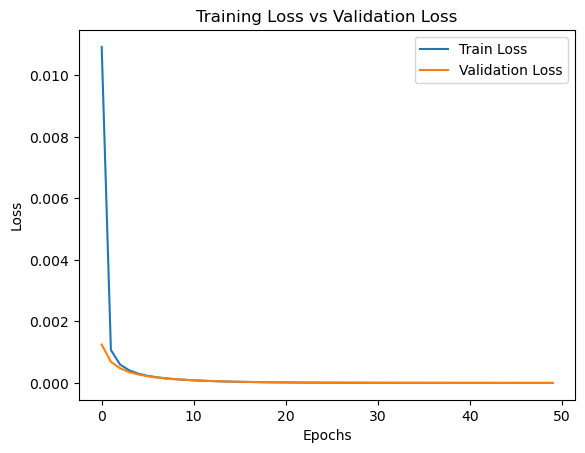

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.kera12.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt
def generate_sequence(seq_length=5,num_samples=1000):
    X,y=[],[]
    for _ in range(num_samples):
        seq=np.random.rand(seq_length)
        X.append(seq)
        y.append(seq[-1]+0.1)
    return np.array(X),np.array(y)

seq_length=5
X,y=generate_sequence(seq_length)
X=X.reshape(X.shape[0],seq_length,1)
split=int(0.8*len(X))
X_train,y_train=X[:split],y[:split]
X_test,y_test=X[split:],y[split:]
model=Sequential([
    SimpleRNN(10,activation='relu',input_shape=(seq_length,1)),
    Dense(1)
])
model.compile(optimizer='adam',loss='mse')
model.summary()
history=model.fit(X_train,y_train,epochs=50,batch_size=16,validation_data=(X_test,y_test))
sample_input=np.array([0.1,0.2,0.3,0.4,0.5]).reshape(1,seq_length,1)
predicted_val=model.predict(sample_input)
print(f"Predicted next value: {predicted_val}")
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss vs Validation Loss')
plt.show()